In [28]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
from logic.clustering_cnn import get_clusters
from logic.database import _compute_window_current, IOS, SIGMA_WHITE


# Simulation Benchmark: Finding the Accuracy Ceiling

The CNN achieves ~75% accuracy for 7 clusters. Is that because the CNN is bad, or because the physics of the simulation makes it impossible to do better?

The core problem is that the measured current at each position is not just from the amino acid at that position -> it is a Gaussian-weighted blend of the 5 amino acids in the sensing window. This blurring can drag two positions with different amino acids (and different cluster labels) to produce nearly identical currents. When that happens, no classifier can tell them apart and that is the ceiling.

1. Show the raw currents and cluster labels for each position in a specific peptide
2. Find which positions are so close in current that they would be confused (blurring + noise)
3. Simulate many random peptides with noise to find the average ceiling accuracy


### **Step 1: Compute the window current and cluster label for each position**

For a specific peptide containing all 20 amino acids, compute the measured current at each position (already blurred by the 5-mer window) and the cluster label assigned based on the central amino acid's identity.

In [29]:
peptide = 'WNHCVMKYDPFLAISREQGT'

from logic.clustering_cnn import get_clusters
from logic.database import _compute_window_current, IOS
aa_to_cluster = get_clusters(7)
bench_df = []
for i, aa in enumerate(peptide):
    score = _compute_window_current(peptide, i)
    bench_df.append({
        'position': i,
        'amino_acid': aa,
        'current': score,
        'normalized_current': score / IOS,
        'cluster': aa_to_cluster[aa]
    })
    print(f"pos {i:2d}  AA={aa}  current={score:.3f} pA  normalized={score/IOS:.4f} aa_cluster = {aa_to_cluster[aa]}")
bench_df = pd.DataFrame(bench_df)

pos  0  AA=W  current=49.677 pA  normalized=0.2070 aa_cluster = 1
pos  1  AA=N  current=67.787 pA  normalized=0.2824 aa_cluster = 5
pos  2  AA=H  current=75.525 pA  normalized=0.3147 aa_cluster = 6
pos  3  AA=C  current=75.220 pA  normalized=0.3134 aa_cluster = 7
pos  4  AA=V  current=68.754 pA  normalized=0.2865 aa_cluster = 6
pos  5  AA=M  current=59.578 pA  normalized=0.2482 aa_cluster = 3
pos  6  AA=K  current=56.026 pA  normalized=0.2334 aa_cluster = 2
pos  7  AA=Y  current=67.871 pA  normalized=0.2828 aa_cluster = 3
pos  8  AA=D  current=84.267 pA  normalized=0.3511 aa_cluster = 4
pos  9  AA=P  current=79.114 pA  normalized=0.3296 aa_cluster = 7
pos 10  AA=F  current=64.144 pA  normalized=0.2673 aa_cluster = 2
pos 11  AA=L  current=64.359 pA  normalized=0.2682 aa_cluster = 3
pos 12  AA=A  current=73.165 pA  normalized=0.3049 aa_cluster = 5
pos 13  AA=I  current=74.402 pA  normalized=0.3100 aa_cluster = 3
pos 14  AA=S  current=72.544 pA  normalized=0.3023 aa_cluster = 5
pos 15  AA

Sort by current to see which positions are close to each other in current space. Positions that are close in current but have **different cluster labels** are the ones the CNN cannot distinguish.

In [30]:
bench_df.sort_values('current')

,position,amino_acid,current,normalized_current,cluster
0,0,W,49.677234,0.206988,1
6,6,K,56.026424,0.233443,2
5,5,M,59.577869,0.248241,3
10,10,F,64.144143,0.267267,2
11,11,L,64.358911,0.268162,3
1,1,N,67.786725,0.282445,5
7,7,Y,67.870987,0.282796,3
4,4,V,68.753744,0.286474,6
15,15,R,70.531108,0.293880,1
14,14,S,72.544404,0.302268,5


<!-- ### **Step 2: Find positions that are confused by window blurring**

For each pair of positions, check if their currents are within 1σ (1 pA) of each other. These are pairs where the window blurring has dragged two different amino acids to nearly the same current value. If they also have different cluster labels, this is an unavoidable confusion —> the CNN sees the same input but is expected to output two different labels.

This uses the raw SIGMA_WHITE = 1 pA, but in practice the effective noise is lower (~0.2 pA) because `mean_current` is averaged over ~25 samples per step. So this is a conservative (pessimistic) estimate of confusion. -->

In [31]:
for i in range(len(bench_df)):
    for j in range(i+1, len(bench_df)):
        if abs(bench_df.iloc[i]['current'] - bench_df.iloc[j]['current']) < 1 * SIGMA_WHITE:
            print(f"CONFUSED: pos {i} ({bench_df.iloc[i]['amino_acid']}, {bench_df.iloc[i]['current']:.2f}, {bench_df.iloc[i]['cluster']}) ↔ pos {j} ({bench_df.iloc[j]['amino_acid']}, {bench_df.iloc[j]['current']:.2f}, {bench_df.iloc[j]['cluster']})")


CONFUSED: pos 1 (N, 67.79, 5) ↔ pos 4 (V, 68.75, 6)
CONFUSED: pos 1 (N, 67.79, 5) ↔ pos 7 (Y, 67.87, 3)
CONFUSED: pos 2 (H, 75.53, 6) ↔ pos 3 (C, 75.22, 7)
CONFUSED: pos 3 (C, 75.22, 7) ↔ pos 13 (I, 74.40, 3)
CONFUSED: pos 4 (V, 68.75, 6) ↔ pos 7 (Y, 67.87, 3)
CONFUSED: pos 10 (F, 64.14, 2) ↔ pos 11 (L, 64.36, 3)
CONFUSED: pos 12 (A, 73.17, 5) ↔ pos 14 (S, 72.54, 5)


### **Step 3: Empirical ceiling: position identification accuracy over 1000 random peptides**

For each random peptide, add realistic noise to each position's current (σ_effective = σ_white / √25, since mean_current averages ~25 samples --> from 5ms dwell* 5000 Hz sampling freq), then ask: using a perfect nearest-neighbour classifier that knows all 20 true currents, can it identify the correct **position**? 

The mean ceiling tells you: on average, what fraction of positions can be correctly identified from the current signal alone, even with a perfect classifier. This is a lower bound on the true ceiling —> the CNN also uses the 4 neighbouring step currents as features, which helps it partially recover confused positions.

In [ ]:
import random
from logic.database import AA_PROPERTIES
import numpy as np
random.seed(42)
N_SAMPLES = 25  # approximate samples per step
sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)
ceilings = []
for _ in range(1000):
    pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))
    currents = [_compute_window_current(pep, i) for i in range(20)]
    correct = 0
    noisy = [c + np.random.normal(0, sigma_effective) for c in currents]
    for i in range(20):
        predicted = min(range(20), key=lambda j: abs(noisy[i] - currents[j]))
        if predicted == i:
            correct += 1
    ceilings.append(correct / 20 * 100)

print(f"Mean ceiling: {np.mean(ceilings):.1f}%")
print(f"Min ceiling:  {np.min(ceilings):.1f}%")
print(f"Max ceiling:  {np.max(ceilings):.1f}%")


Mean ceiling: 87.9%
Min ceiling:  60.0%
Max ceiling:  100.0%


### **Step 4: Cluster accuracy ceiling**

Same as Step 3 but now score by **cluster accuracy** instead of position accuracy. Two positions being confused only counts as an error if they belong to **different clusters** — matching what the CNN is actually asked to do. This gives a higher ceiling than Step 3 and is the correct number to compare against the CNN's 75%.

In [ ]:
import random
from logic.database import AA_PROPERTIES
random.seed(42)
N_SAMPLES = 25  # approximate samples per step
sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)
ceilings = []
for _ in range(1000):
    pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))
    currents = [_compute_window_current(pep, i) for i in range(20)]
    correct = 0
    noisy = [c + np.random.normal(0, sigma_effective) for c in currents]
    for i in range(20):
        predicted = min(range(20), key=lambda j: abs(noisy[i] - currents[j]))
        if aa_to_cluster[pep[predicted]] == aa_to_cluster[pep[i]]:
            correct += 1
    ceilings.append(correct / 20 * 100)

print(f"Mean ceiling: {np.mean(ceilings):.1f}%")
print(f"Min ceiling:  {np.min(ceilings):.1f}%")
print(f"Max ceiling:  {np.max(ceilings):.1f}%")


Mean ceiling: 90.7%
Min ceiling:  60.0%
Max ceiling:  100.0%


### **K-mer space coverage**

How much of the possible 5-mer space does the training data cover? With 20 amino acids and 5-mer windows there are 20^5 = 3.2 million possible k-mers. With 10,000 traces of 20 amino acids each, you get 160,000 k-mer instances. How many of those are unique, and what fraction of the full space does that represent?

In [ ]:
db = pd.read_csv('../data/nanopore_trace_database.csv')
sequences = db.groupby('trace_id')['peptide_sequence'].first()

kmers = []
for seq in sequences:
    for i in range(len(seq) - 5 + 1):
        kmers.append(seq[i:i+5])

print(f"Total 5-mer instances: {len(kmers)}")
print(f"Unique 5-mers seen:    {len(set(kmers))}")
print(f"Total possible 5-mers: {20**5:,}")
print(f"Coverage:              {len(set(kmers)) / 20**5 * 100:.2f}%")


Total 5-mer instances: 160000
Unique 5-mers seen:    156038
Total possible 5-mers: 3,200,000
Coverage:              4.88%


#### **since we're doing 7-way classification and not 20-way classification with the clusters, cluster diversity is more important**

In [45]:
features = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
features = features.copy()
possible_sequences = []
sequences = features.groupby('trace_id')
n_clusters = 7
aa_to_cluster = get_clusters(n_clusters)
features['label'] = features['amino_acid'].map(aa_to_cluster) - 1
features.head()
for name, seq in sequences:
    for i in range(len(seq) - 5 + 1):
        possible_sequences.append(''.join(seq['label'].iloc[i:i+5].astype(str)))
print(f"Total 5-mer instances: {len(possible_sequences)}")
print(f"Unique 5-mers seen:    {len(set(possible_sequences))}")
print(f"Total possible 5-mers: {n_clusters**5}")
print(f"Coverage:              {len(set(possible_sequences)) / n_clusters**5 * 100:.2f}%")

Total 5-mer instances: 159981
Unique 5-mers seen:    16413
Total possible 5-mers: 16807
Coverage:              97.66%


In [ ]:
# from collections import Counter
# kmer_counts = Counter(kmers)
# counts = list(kmer_counts.values())
# print(f"Seen only once:  {sum(1 for c in counts if c == 1)}")
# print(f"Seen 2-5 times:  {sum(1 for c in counts if 2 <= c <= 5)}")
# print(f"Seen >5 times:   {sum(1 for c in counts if c > 5)}")


Seen only once:  152137
Seen 2-5 times:  3901
Seen >5 times:   0


Almost every k-mer is seen only once there are virtually no repeats. This confirms the CNN cannot be memorising k-mers. It must be learning the underlying physics (how volume, charge, hydrophobicity map to current) to generalise.

In [ ]:
# for a test peptide, how many of its 16 k-mers were seen in training?
test_pep = ''.join(random.choices(list(AA_PROPERTIES.keys()), k=20))

seen_training = set(kmers)
for i in range(len(test_pep) - 5 + 1):
    kmer = test_pep[i:i+5]
    seen = kmer in seen_training
    print(f"pos {i:2d}: {kmer}  {'seen in training' if seen else 'UNSEEN'}")


pos  0: LFVFK  UNSEEN
pos  1: FVFKY  UNSEEN
pos  2: VFKYR  UNSEEN
pos  3: FKYRA  UNSEEN
pos  4: KYRAY  UNSEEN
pos  5: YRAYQ  UNSEEN
pos  6: RAYQK  UNSEEN
pos  7: AYQKF  UNSEEN
pos  8: YQKFM  UNSEEN
pos  9: QKFMY  UNSEEN
pos 10: KFMYN  UNSEEN
pos 11: FMYNT  UNSEEN
pos 12: MYNTT  UNSEEN
pos 13: YNTTR  UNSEEN
pos 14: NTTRT  UNSEEN
pos 15: TTRTY  UNSEEN


Even though every k-mer in a test peptide is unseen, the CNN can still generalise because each amino acid has been seen in ~7,800 different neighbour contexts during training. The CNN has learned what each amino acid contributes to the current regardless of what surrounds it.

In [ ]:
from collections import defaultdict
aa_contexts = defaultdict(set)
for seq in sequences:
    for i in range(2, len(seq) - 2):  # full windows only
        center = seq[i]
        context = seq[i-2:i+3]
        aa_contexts[center].add(context)

for aa in sorted(aa_contexts.keys()):
    print(f"{aa}: {len(aa_contexts[aa])} unique contexts seen")


A: 7800 unique contexts seen
C: 7604 unique contexts seen
D: 7850 unique contexts seen
E: 7854 unique contexts seen
F: 7768 unique contexts seen
G: 7926 unique contexts seen
H: 7908 unique contexts seen
I: 7800 unique contexts seen
K: 7729 unique contexts seen
L: 7767 unique contexts seen
M: 7792 unique contexts seen
N: 7839 unique contexts seen
P: 7853 unique contexts seen
Q: 7764 unique contexts seen
R: 7754 unique contexts seen
S: 7830 unique contexts seen
T: 7810 unique contexts seen
V: 7932 unique contexts seen
W: 7786 unique contexts seen
Y: 7672 unique contexts seen


### **Step 6: Current distribution overlap per cluster**
Plot the distribution of measured `mean_current` values for each cluster across all 10,000 traces. Where two clusters' histograms overlap, the CNN receives the same current value with two different cluster labels in its training data — it literally cannot learn to separate those cases.

The distributions are wide (not tight Gaussians) because the window blurring shifts each amino acid's current depending on its neighbours. The overlap between clusters is the direct visual representation of the ceiling.

This is for the worst case scenario where only the center current is known

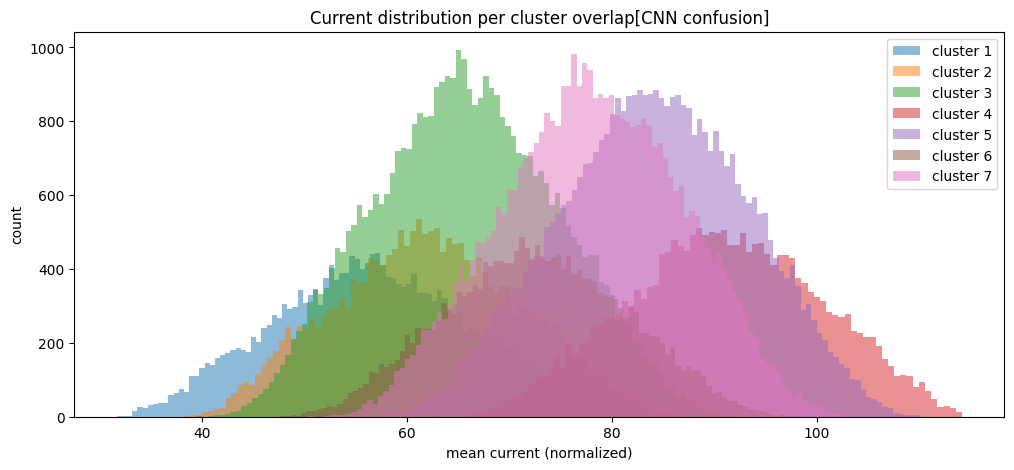

In [36]:
df = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
aa_to_cluster = get_clusters(7)
df['cluster'] = df['amino_acid'].map(aa_to_cluster)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]['mean_current']
    ax.hist(subset, bins=100, alpha=0.5, label=f'cluster {cluster_id}')

ax.set_xlabel('mean current (normalized)')
ax.set_ylabel('count')
ax.legend()
plt.title('Current distribution per cluster overlap[CNN confusion]')
plt.show()




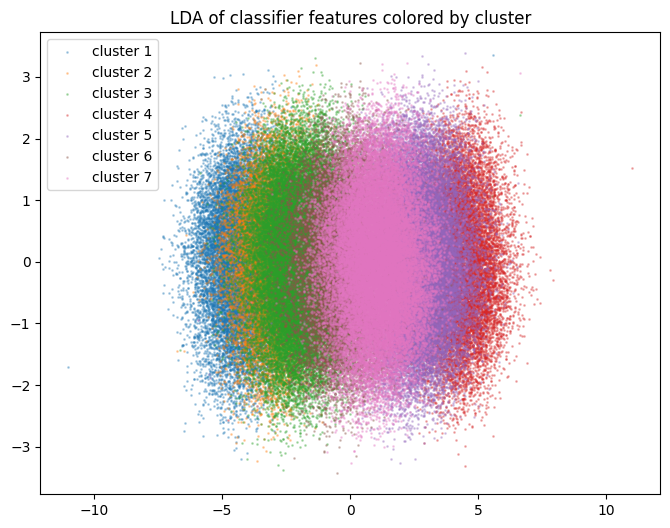

In [48]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis




feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
X = df[feature_cols].dropna()
labels = df.loc[X.index, 'cluster']
lda = LinearDiscriminantAnalysis(n_components=2)
proj = lda.fit_transform(X, labels)

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(labels.unique()):
    mask = labels == c
    ax.scatter(proj[mask, 0], proj[mask, 1], s=1, alpha=0.3, label=f'cluster {c}')
ax.legend()
plt.title('LDA of classifier features colored by cluster')
plt.show()


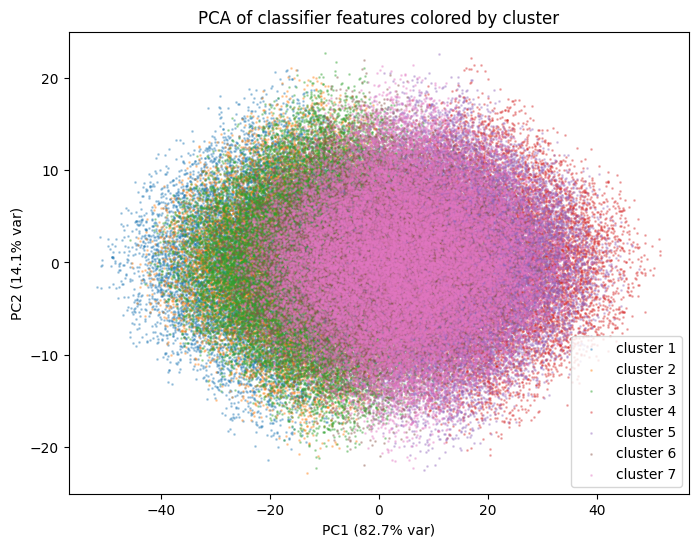

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis




feature_cols = ['mean_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
X = df[feature_cols].dropna()
labels = df.loc[X.index, 'cluster']
pca = PCA(n_components=2)
proj = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(labels.unique()):
    mask = labels == c
    ax.scatter(proj[mask, 0], proj[mask, 1], s=1, alpha=0.3, label=f'cluster {c}')
ax.legend()
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of classifier features colored by cluster')
plt.show()


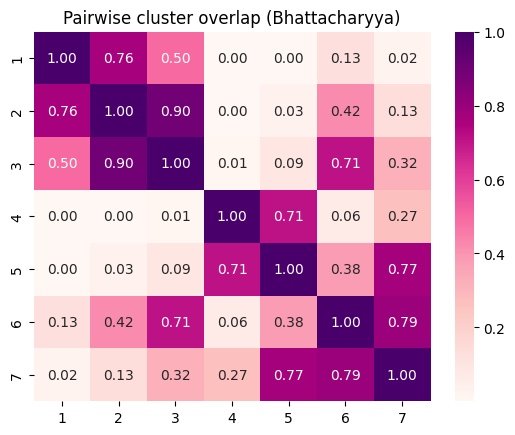

In [57]:
import numpy as np
from scipy.stats import multivariate_normal

def bhattacharyya(mu1, cov1, mu2, cov2):
    cov_avg = (cov1 + cov2) / 2
    delta = mu1 - mu2
    term1 = 0.125 * delta @ np.linalg.inv(cov_avg) @ delta
    term2 = 0.5 * np.log(np.linalg.det(cov_avg) / np.sqrt(np.linalg.det(cov1) * np.linalg.det(cov2)))
    return np.exp(-(term1 + term2))

# compute pairwise overlap in LDA space
clusters = sorted(labels.unique())
overlap = pd.DataFrame(index=clusters, columns=clusters, dtype=float)
for i in clusters:
    for j in clusters:
        Xi = proj[labels == i]
        Xj = proj[labels == j]
        overlap.loc[i, j] = bhattacharyya(Xi.mean(0), np.cov(Xi.T), Xj.mean(0), np.cov(Xj.T))

import seaborn as sns
sns.heatmap(overlap, annot=True, fmt='.2f', cmap='RdPu')
plt.title('Pairwise cluster overlap (Bhattacharyya)')
plt.show()


In [60]:
import numpy as np

def permutation_importance(model, X, y, feature_names):
    baseline = model.evaluate(X, y, verbose=0)[1]  # baseline accuracy
    importances = []
    for i in range(X.shape[-1]):
        X_perm = X.copy()
        X_perm[:, :, i] = np.random.permutation(X_perm[:, :, i])
        score = model.evaluate(X_perm, y, verbose=0)[1]
        importances.append(baseline - score)
    return dict(zip(feature_names, importances))




In [63]:
feature_cols = [
    'mean_current',
    'mean_minus2',
    'mean_minus1',
    'mean_plus1',
    'mean_plus2'
]
from tensorflow.keras.models import load_model

model_7 = load_model('model7.keras')
X_test_7 = np.load('X_test_7.npy')
y_test_7 = np.load('y_test_7.npy')
feature_importances = permutation_importance(model_7, X_test_7, y_test_7, feature_cols)
print("Permutation Importances:", feature_importances)

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Permutation Importances: {'mean_current': 0.4544544517993927, 'mean_minus2': 0.02642643451690674, 'mean_minus1': 0.3198949694633484, 'mean_plus1': 0.2941691279411316, 'mean_plus2': 0.021021127700805664}


In [56]:
# df = pd.read_csv('../data/nanopore_feature_by_cluster.csv')
# aa_to_cluster = get_clusters(7)
# df['cluster'] = df['amino_acid'].map(aa_to_cluster)

# # for each step, get the cluster pattern of its 5-mer window
# # you already have mean_current and the neighbour currents as features
# feature_cols = ['mean_minus2', 'mean_minus1', 'mean_current', 'mean_plus1', 'mean_plus2']
# df_clean = df.dropna(subset=feature_cols)

# # find pairs of steps with different cluster labels but similar mean_current
# confused = 0
# total = 0
# N_SAMPLES = 25
# sigma_effective = SIGMA_WHITE / np.sqrt(N_SAMPLES)

# for cluster_a in sorted(df_clean['cluster'].unique()):
#     for cluster_b in sorted(df_clean['cluster'].unique()):
#         if cluster_b <= cluster_a:
#             continue
#         curr_a = df_clean[df_clean['cluster'] == cluster_a]['mean_current']
#         curr_b = df_clean[df_clean['cluster'] == cluster_b]['mean_current']
#         # how many steps from cluster_a fall within noise of cluster_b's range?
#         overlap = ((curr_a >= curr_b.min()) & (curr_a <= curr_b.max())).sum()
#         print(f"cluster {cluster_a} vs {cluster_b}: {overlap} overlapping steps")
